# Week 2 — Notebook 1: Market Data Loading

In this notebook you will:
- Define project constants (paths, tickers, dates)
- Download OHLCV data for every market symbol and save it to `data/raw/`
- Explore the downloaded data and compute basic return statistics
- Compare multiple symbols with normalised return plots

Fill in every `# TODO` cell before moving to `technical_indicators.ipynb`.

---

## 0. Install & Import Libraries

In [1]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab / fresh env

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

print('Libraries imported!')

Libraries imported!


/Users/azimahmed/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


---

## 1. Project Configuration

Define all constants that the project relies on. These same constants are used in every notebook and script this week, so get them right here first.

| Constant | Purpose |
|---|---|
| `BASE_DIR` | Root of the project (notebook's working directory) |
| `RAW_DIR` | `BASE_DIR/data/raw` — raw OHLCV CSVs |
| `PROCESSED_DIR` | `BASE_DIR/data/processed` — feature-engineered CSVs |
| `START_DATE` | Earliest date to download (`"2015-01-01"`) |
| `END_DATE` | `None` → today |
| `MARKET_SYMBOLS` | Dict: market name → list of Yahoo Finance ticker strings |

> 💡 Use `Path.cwd()` as the base when running inside a notebook.

In [2]:
# TODO 1.1 — Define directory paths and create them on disk
from pathlib import Path

BASE_DIR      = Path.cwd()
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

# Create the directories
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

RAW_DIR      : /Users/azimahmed/Desktop/Github:stock/SOC-Stock-Trading-With-LSTM-And-RL/Week2/data/raw
PROCESSED_DIR: /Users/azimahmed/Desktop/Github:stock/SOC-Stock-Trading-With-LSTM-And-RL/Week2/data/processed


In [3]:
# TODO 1.2 — Define the date range and market symbol universe
START_DATE = '2015-01-01'
END_DATE   = None

# Define the market symbols dictionary
MARKET_SYMBOLS = {
    'india':  ['^NSEI', '^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS'],
    'us':     ['^GSPC', '^IXIC', 'SPY', 'AAPL', 'MSFT', 'NVDA', 'TSLA'],
    'crypto': ['BTC-USD', 'ETH-USD'],
    'forex':  ['EURUSD=X', 'JPY=X'],
}

print('Markets :', list(MARKET_SYMBOLS.keys()))
print('Symbols :', sum(len(v) for v in MARKET_SYMBOLS.values()), 'total')

Markets : ['india', 'us', 'crypto', 'forex']
Symbols : 16 total


In [4]:
# TODO 1.3 — Implement safe_symbol()
def safe_symbol(symbol: str) -> str:
    return symbol.replace('^', '').replace('.', '_').replace('-', '_').replace('=', '_')

# Smoke-test
assert safe_symbol('^NSEI')       == 'NSEI'
assert safe_symbol('RELIANCE.NS') == 'RELIANCE_NS'
assert safe_symbol('BTC-USD')     == 'BTC_USD'
assert safe_symbol('EURUSD=X')    == 'EURUSD_X'
print('safe_symbol() passed!')

safe_symbol() passed!


---

## 2. OHLCV Data Structure

Every downloaded file will have these columns (lowercase, normalised by us):

| Column | Description |
|---|---|
| `date` | Trading date |
| `open` | Price at market open |
| `high` | Intraday high |
| `low` | Intraday low |
| `close` | Price at market close |
| `adj_close` | Close adjusted for dividends and splits |
| `volume` | Shares / contracts traded |
| `symbol` | Ticker string (added by the download function) |

> The **close** price is used for all technical indicators. `adj_close` is preferred for long-term return calculations.

---

## 3. Download All Market Symbols → `data/raw/`

Implement the download pipeline step by step.

Each raw CSV must have lowercase column names, a `symbol` column, and be saved as `data/raw/<safe_symbol>.csv`.

In [5]:
# TODO 3.1 — Implement download_symbol()
def download_symbol(symbol: str, start: str = START_DATE, end=END_DATE) -> pd.DataFrame:
    # 1. Call yf.download()
    data = yf.download(symbol, start=start, end=end, auto_adjust=False, progress=False)
    
    # 2. Raise ValueError if empty
    if data.empty:
        raise ValueError(f"No data found for {symbol}")
        
    # 3. Flatten MultiIndex (in case yfinance returns it)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
        
    # 4. Reset index so 'Date' becomes a column
    data = data.reset_index()
    
    # 5. Normalise column names: lowercase, replace spaces with underscores
    data.columns = [c.lower().replace(' ', '_') for c in data.columns]
    
    # 6. Add 'symbol' column
    data['symbol'] = symbol
    
    return data

# Quick test
test_df = download_symbol('SPY')
print(test_df.shape)
print(test_df.columns.tolist())
test_df.head()

(2873, 8)
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol']


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.124985,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052567,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479126,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541214,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514191,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [6]:
# TODO 3.2 — Download every symbol and save to RAW_DIR
for market, symbols in MARKET_SYMBOLS.items():
    for symbol in symbols:
        try:
            print(f"Downloading {symbol}...")
            df = download_symbol(symbol)
            # Save to CSV
            out_path = RAW_DIR / f"{safe_symbol(symbol)}.csv"
            df.to_csv(out_path, index=False)
        except Exception as e:
            print(f"Failed to download {symbol}: {e}")

print("Download complete!")

Download complete!


---

## 4. Load & Explore a Single Symbol

Before computing indicators, get familiar with the raw data for one symbol.

In [7]:
# TODO 4.1
SYMBOL = 'SPY'
df = pd.read_csv(RAW_DIR / f'{safe_symbol(SYMBOL)}.csv', parse_dates=['date'])
df = df.sort_values('date')

print('Shape :', df.shape)
print('Dtypes:\n', df.dtypes)
df.head()

Shape : (2873, 8)
Dtypes:
 date         datetime64[ns]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
symbol               object
dtype: object


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.124969,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052628,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479156,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541199,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514221,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [8]:
# TODO 4.2
close = df['close']
returns = close.pct_change().dropna()

mean_daily_return = returns.mean()
daily_std = returns.std()
annualised_vol = daily_std * np.sqrt(252)
total_cum_return = (close.iloc[-1] / close.iloc[0]) - 1

# Find dates of high/low
ath_date = df.loc[df['close'].idxmax(), 'date']
atl_date = df.loc[df['close'].idxmin(), 'date']

print(f"Mean Daily Return:     {mean_daily_return:.6f}")
print(f"Daily Volatility:      {daily_std:.6f}")
print(f"Annualised Volatility: {annualised_vol:.4f}")
print(f"Total Return:          {total_cum_return:.2%}")
print(f"All-Time High Date:    {ath_date.date()}")
print(f"All-Time Low Date:     {atl_date.date()}")

Mean Daily Return:     0.000510
Daily Volatility:      0.011160
Annualised Volatility: 0.1772
Total Return:          261.91%
All-Time High Date:    2026-06-02
All-Time Low Date:     2016-02-11


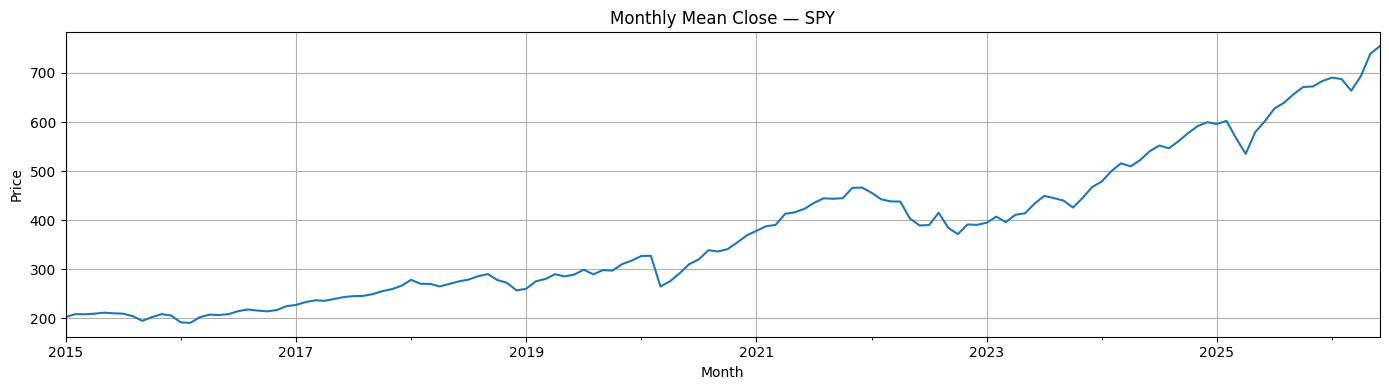

In [9]:
# TODO 4.3 — Resample close to monthly mean and plot
monthly_close = df.set_index('date')['close'].resample('ME').mean()

plt.figure(figsize=(14, 4))
monthly_close.plot()
plt.title(f'Monthly Mean Close — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Price')
plt.grid(True); plt.tight_layout(); plt.show()

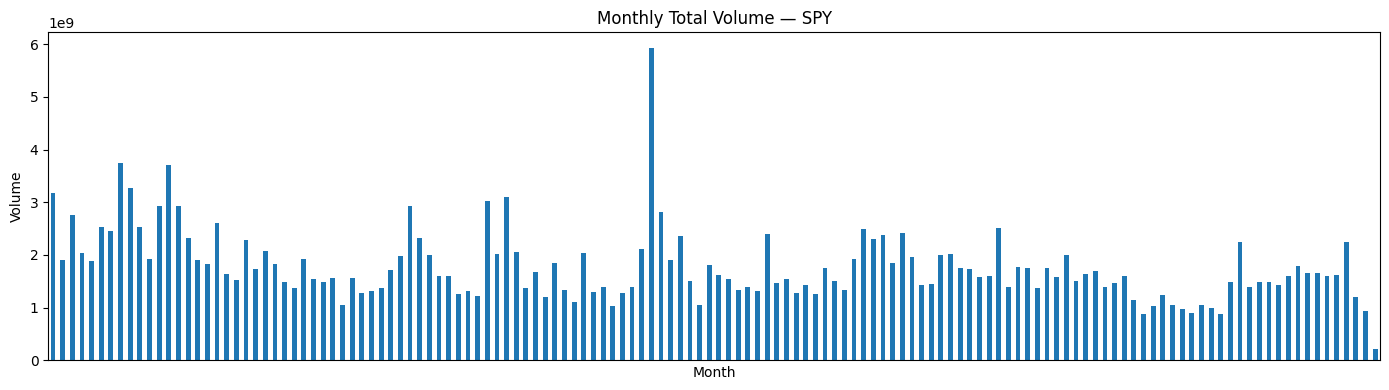

In [10]:
# TODO 4.4 — Resample volume to monthly total and plot
monthly_vol = df.set_index('date')['volume'].resample('ME').sum()

plt.figure(figsize=(14, 4))
monthly_vol.plot(kind='bar')
plt.title(f'Monthly Total Volume — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Volume')
plt.xticks([]) # Hiding labels for clarity if needed
plt.tight_layout(); plt.show()

---

## 5. Multi-Symbol Comparison

Normalised cumulative returns let you compare symbols regardless of their absolute price level. Dividing each series by its first value sets every series to start at 1.0.

In [11]:
# TODO 5.1 — Load US symbols
us_closes = pd.DataFrame()
for sym in MARKET_SYMBOLS['us']:
    try:
        data = pd.read_csv(RAW_DIR / f"{safe_symbol(sym)}.csv", parse_dates=['date'], index_col='date')
        us_closes[sym] = data['close']
    except Exception as e:
        print(f"Could not load {sym}: {e}")

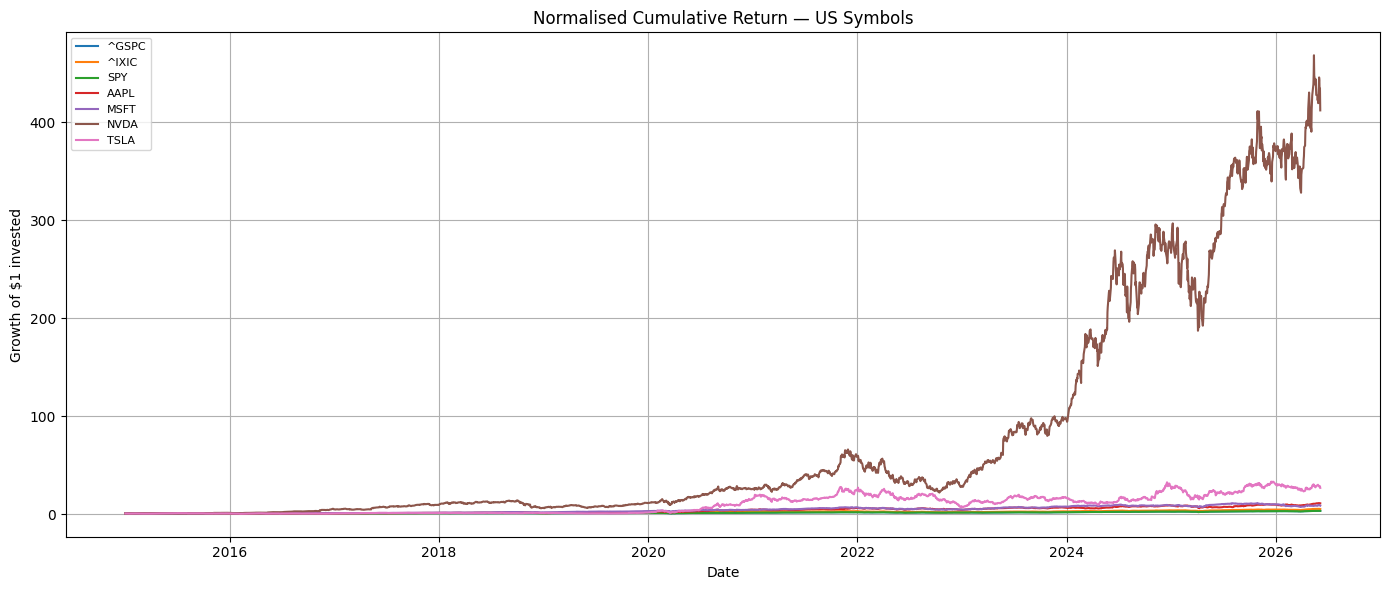

In [12]:
# TODO 5.2 — Normalize and plot
# Forward-fill gaps, normalize to 1.0, and plot
normalized_us = us_closes.ffill().dropna()
normalized_us = normalized_us / normalized_us.iloc[0]

plt.figure(figsize=(14, 6))
for col in normalized_us.columns:
    plt.plot(normalized_us.index, normalized_us[col], label=col)

plt.title('Normalised Cumulative Return — US Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

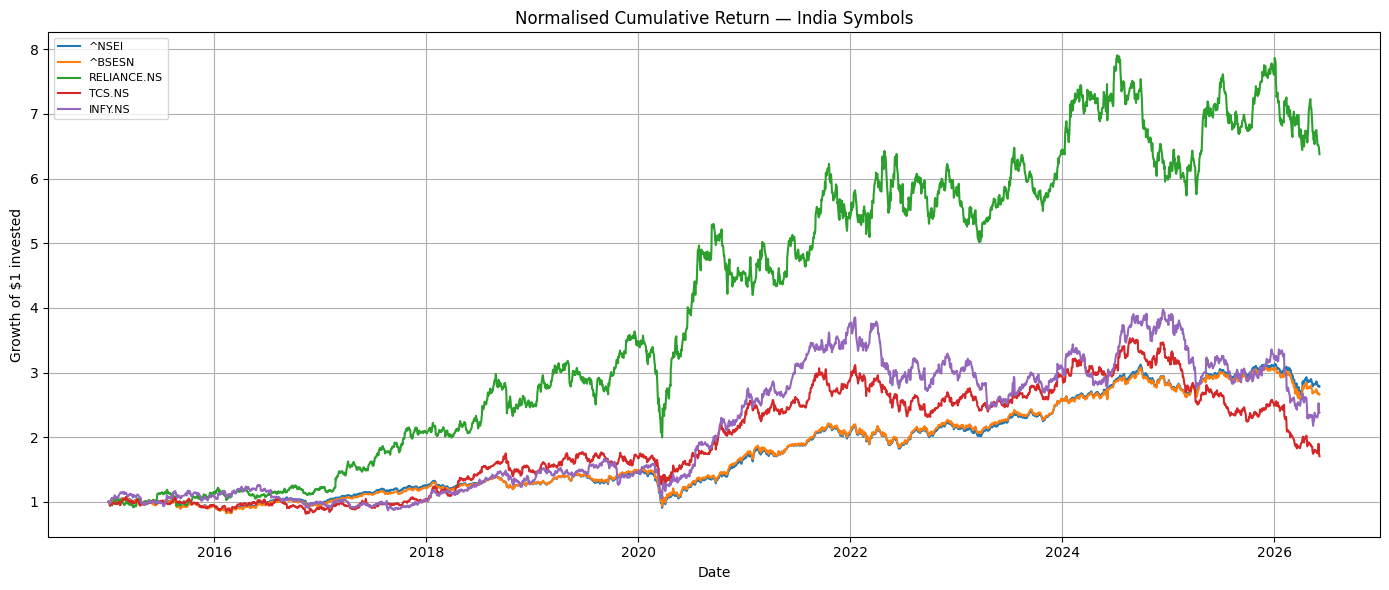

In [13]:
# TODO 5.3 — Load India symbols
india_closes = pd.DataFrame()
for sym in MARKET_SYMBOLS['india']:
    try:
        data = pd.read_csv(RAW_DIR / f"{safe_symbol(sym)}.csv", parse_dates=['date'], index_col='date')
        india_closes[sym] = data['close']
    except Exception as e:
        print(f"Could not load {sym}: {e}")

# Normalize and plot
normalized_india = india_closes.ffill().dropna()
normalized_india = normalized_india / normalized_india.iloc[0]

plt.figure(figsize=(14, 6))
for col in normalized_india.columns:
    plt.plot(normalized_india.index, normalized_india[col], label=col)

plt.title('Normalised Cumulative Return — India Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

---
